# Step 1: Import Required Libraries

In [35]:
# Data Handling
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [36]:
df = pd.read_csv('GB-HR-Employee-Attrition.csv')

print(df.shape)

df.head(5)

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Step 3: Basic Information

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [38]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Step 4: Check Missing Values

In [39]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Step 5: Target Variable Distribution

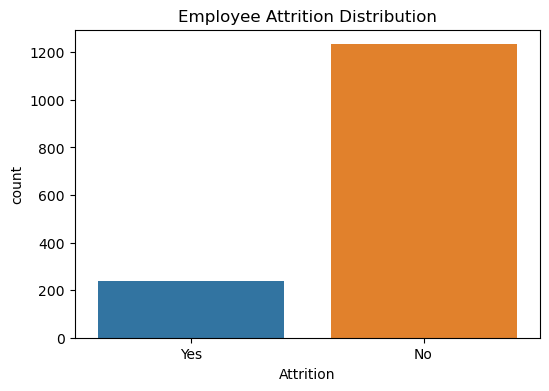

In [40]:
plt.figure(figsize = (6,4))

sns.countplot(x = "Attrition", data = df)

plt.title("Employee Attrition Distribution")

plt.show()

# Step 6: Attrition Percentage

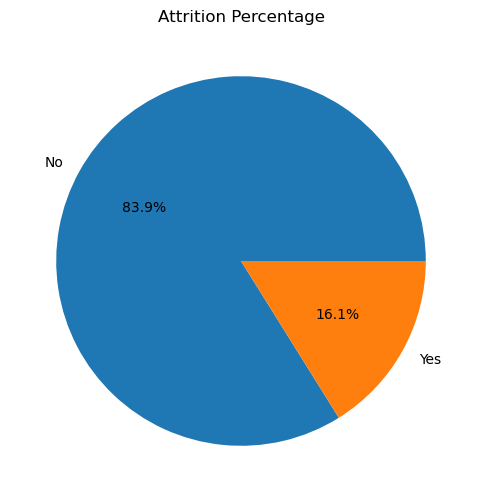

In [41]:
attrition_count = df['Attrition'].value_counts()

plt.figure(figsize = (6,6))

plt.pie(
    attrition_count,
    labels = attrition_count.index,
    autopct = "%1.1f%%"
)

plt.title("Attrition Percentage")

plt.show()

# Step 7: Department Wise Attrition

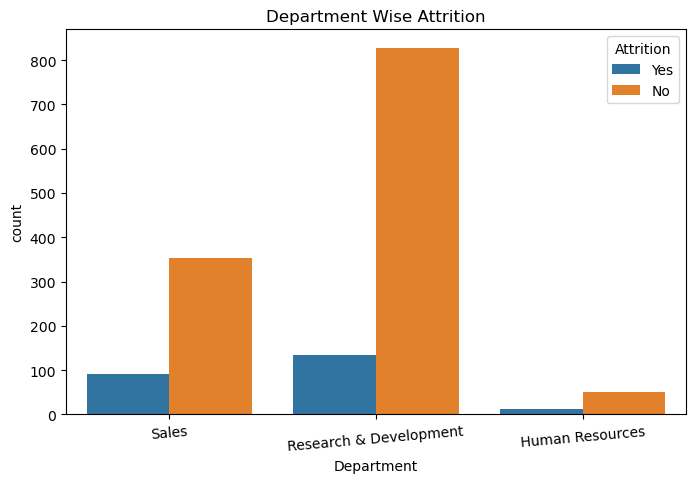

In [42]:
plt.figure(figsize = (8,5))

sns.countplot(
    x = "Department",
    hue = "Attrition",
    data = df
)

plt.xticks(rotation = 5)

plt.title("Department Wise Attrition")

plt.show()

# Step 8: Overtime vs Attrition

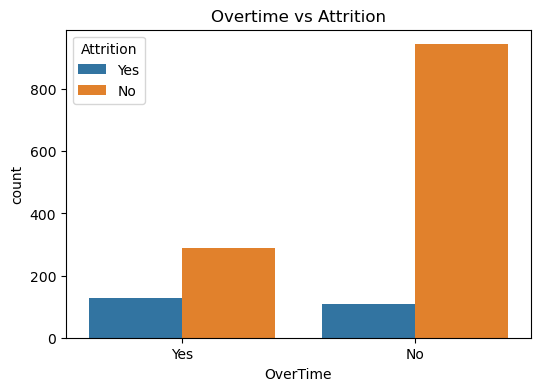

In [43]:
plt.figure(figsize = (6,4))

sns.countplot(
    x = "OverTime",
    hue = "Attrition",
    data = df
)

plt.title("Overtime vs Attrition")

plt.show()

# Step 9: Monthly Income Distribution

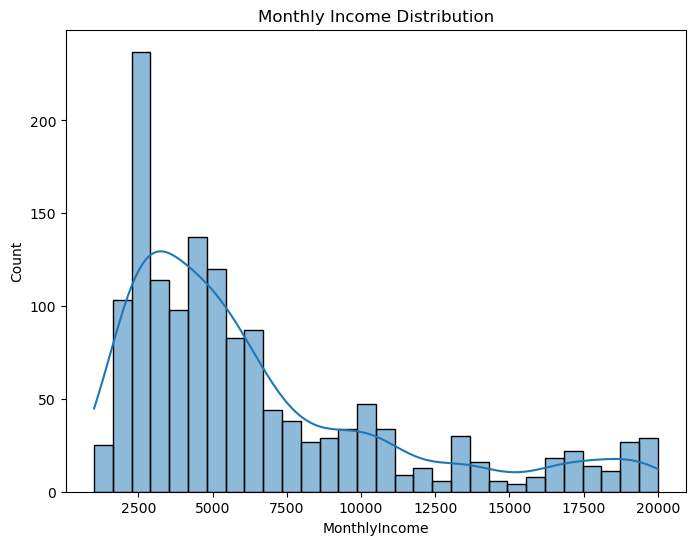

In [44]:
plt.figure(figsize = (8,6))

sns.histplot(
    df['MonthlyIncome'],
    kde = True,
    bins = 30
)

plt.title("Monthly Income Distribution")

plt.show()

# Step 10: Age Distribution

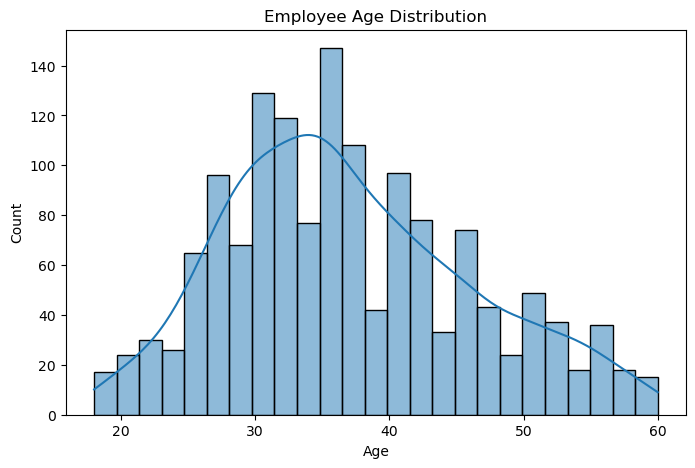

In [45]:
plt.figure(figsize = (8,5))

sns.histplot(
    df["Age"],
    kde = True,
    bins = 25
)

plt.title("Employee Age Distribution")

plt.show()

# Step 11: Remove Constant Columns

In [46]:
df.drop(
    [
        "EmployeeCount",
        "Over18",
        "StandardHours",
        "EmployeeNumber"
    ],
    axis = 1,
    inplace = True
)

# Step 12: Encode Categorical Variables

In [49]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])
        

# Step 13: Correlation Heatmap

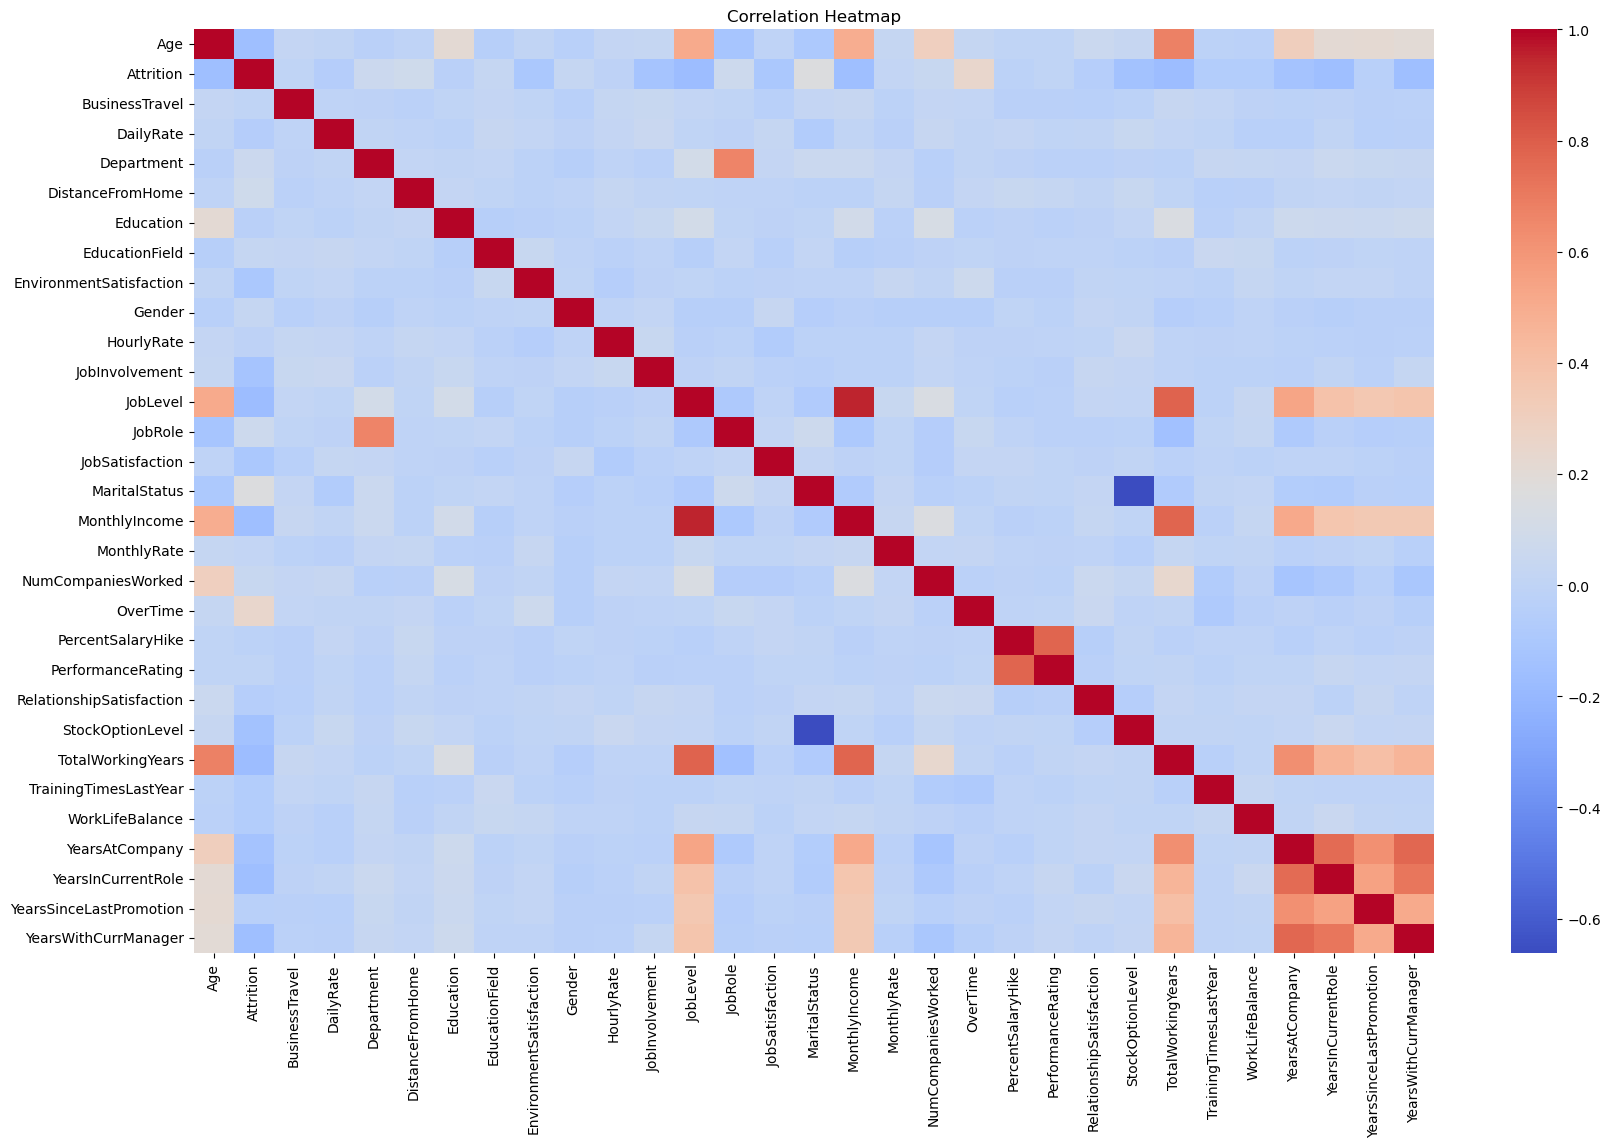

In [50]:
plt.figure(figsize = (20,12))

sns.heatmap(
    df.corr(),
    cmap = "coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Step 14: Define Features and Target

In [51]:
X = df.drop("Attrition", axis = 1)

y = df["Attrition"]

# Step 15: Train Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print(X_train.shape)
print(X_test.shape)

(1176, 30)
(294, 30)


# Step 16: Build Gradient Boosting Model

In [54]:
gb_model = GradientBoostingClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 4,
    random_state = 42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
                           random_state=42)

# Step 17: Prediction

In [55]:
y_pred = gb_model.predict(X_test)

y_prob = gb_model.predict_proba(X_test)[:,1]

# Step 18: Accuracy Score

In [57]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), '%')

Accuracy : 83.67 %


# Step 19: Confusion Matrix

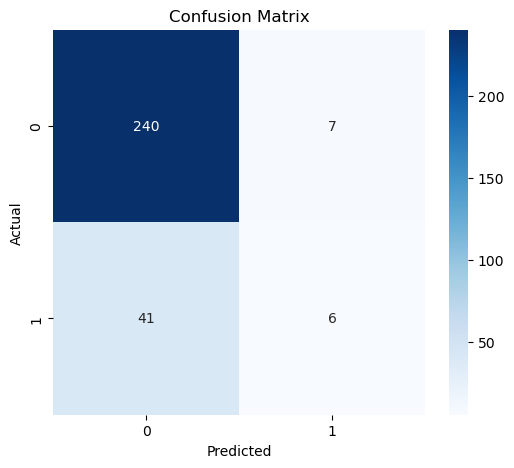

In [60]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,5))

sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 20: Classification Report

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.46      0.13      0.20        47

    accuracy                           0.84       294
   macro avg       0.66      0.55      0.55       294
weighted avg       0.79      0.84      0.80       294



# Step 21: ROC Curve

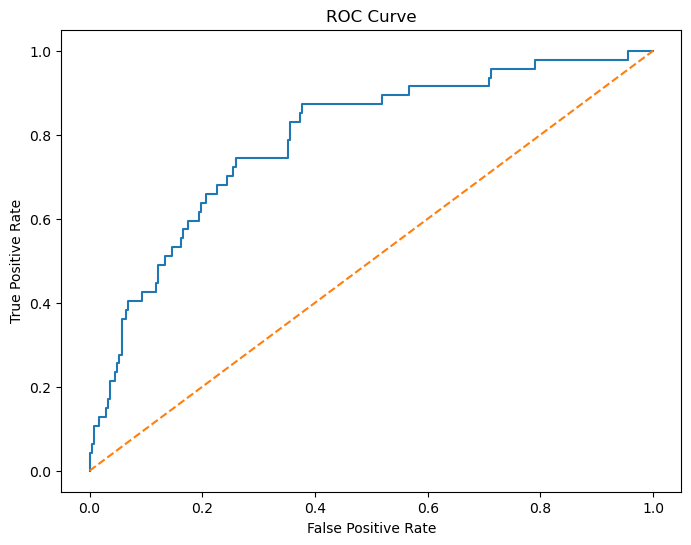

In [63]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize = (8,6))

plt.plot(fpr, tpr, label = f"AUC = {auc_score:.4f}")

plt.plot([0,1], [0,1], '--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# Step 22: AUC Score

In [64]:
print("AUC Score :", round(auc_score,4))

AUC Score : 0.7891


# Step 23: Feature Importance

In [66]:
importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : gb_model.feature_importances_
})

importance = importance.sort_values(
    by = "Importance",
    ascending = False
)

importance.head(15)

,Feature,Importance
15,MonthlyIncome,0.117675
23,TotalWorkingYears,0.093252
0,Age,0.091720
18,OverTime,0.066549
2,DailyRate,0.056507
12,JobRole,0.053341
4,DistanceFromHome,0.048444
9,HourlyRate,0.045586
7,EnvironmentSatisfaction,0.044875
17,NumCompaniesWorked,0.040205


# Step 24: Top Features Graph

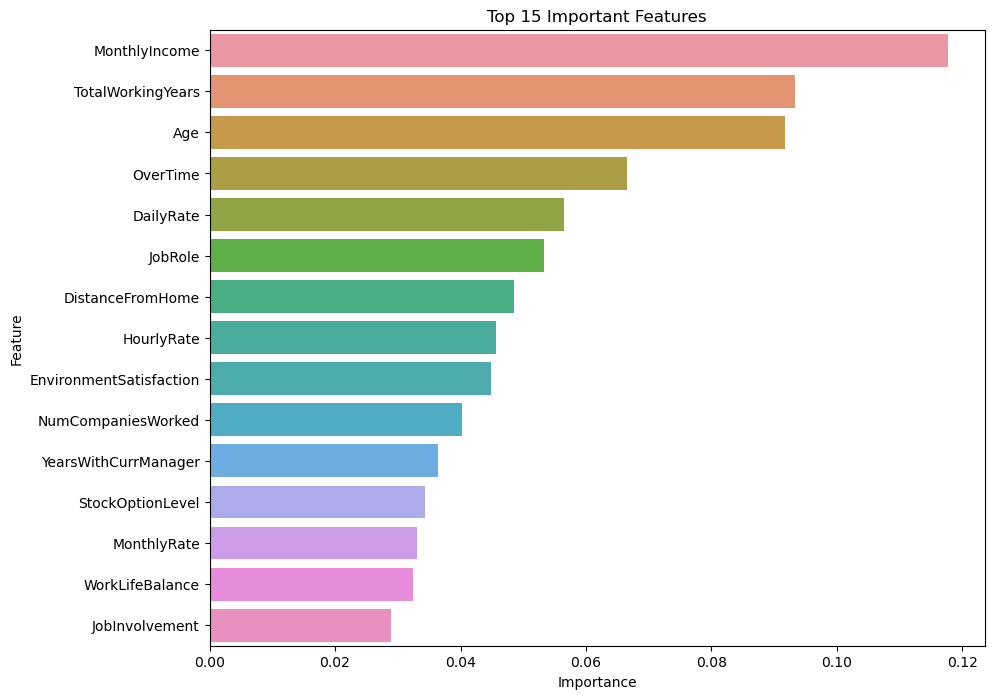

In [67]:
plt.figure(figsize = (10,8))

sns.barplot(
    x = "Importance",
    y = "Feature",
    data = importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

# Step 25: Training Accuracy

In [68]:
train_pred = gb_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy :", round(train_acc*100,2))

Training Accuracy : 98.89


# Step 26: Testing Accuracy

In [70]:
test_acc = accuracy_score(y_test, y_pred)

print("Testing Accuracy :", round(test_acc*100,2))

Testing Accuracy : 83.67


# Step 27: Overfitting Check

In [71]:
difference = train_acc - test_acc

print("Training Accuracy :", round(train_acc*100,2))

print("Testing Accuracy :", round(test_acc*100,2))

print("Difference :", round(difference*100,2))

Training Accuracy : 98.89
Testing Accuracy : 83.67
Difference : 15.22


# Step 28: Actual vs Predicted

In [72]:
results = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})

results.head(20)

,Actual,Predicted
1061,0,0
891,0,0
456,0,0
922,0,0
69,1,0
1164,0,0
406,0,0
1330,0,0
1232,0,0
1311,0,0


# Step 29: Employee Attrition Probability

In [73]:
probability_df = pd.DataFrame({
    "Actual" : y_test,
    "Attrition_Prabability" : y_prob
})

probability_df.head(20)

,Actual,Attrition_Prabability
1061,0,0.322864
891,0,0.005818
456,0,0.057496
922,0,0.006983
69,1,0.166368
1164,0,0.079827
406,0,0.035659
1330,0,0.022127
1232,0,0.012907
1311,0,0.441252


# Step 30: Save Model

In [74]:
import joblib

joblib.dump(
    gb_model,
    "GradientBoosting_EmployeeAttrition.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
